In [7]:
# Cell 1 — install + imports
!pip install transformers jiwer -q
import os, torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from jiwer import cer, wer

In [8]:
# Cell 2 — add your project-trocr output as input dataset first
# In Kaggle: Add Data → Your Work → project-trocr → add output
# Then the model will be at:
MODEL_PATH = "/kaggle/input/notebooks/ayoubaziba/project-trocr/best_model"

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
model     = VisionEncoderDecoderModel.from_pretrained(MODEL_PATH).to(device)
model.eval()
print("Model loaded on", device)

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Model loaded on cuda


In [9]:
# Cell 3 — rebuild test crops only (fast ~2 min, no training data needed)
BASE = "/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019"

def parse_box_file(box_path):
    samples = []
    with open(box_path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(",", 8)
            if len(parts) < 9: continue
            coords = list(map(int, parts[:8]))
            text   = parts[8].strip()
            if not text: continue
            xs = coords[0::2]
            ys = coords[1::2]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            samples.append((bbox, text))
    return samples

def build_test_manifest():
    img_dir = os.path.join(BASE, "test", "img")
    box_dir = os.path.join(BASE, "test", "box")
    os.makedirs("/kaggle/working/test_crops", exist_ok=True)
    manifest = []
    ids = sorted([f[:-4] for f in os.listdir(img_dir) if f.endswith(".jpg")])
    for i, rid in enumerate(ids):
        img  = Image.open(f"{img_dir}/{rid}.jpg").convert("RGB")
        boxes = parse_box_file(f"{box_dir}/{rid}.txt")
        for bbox, text in boxes:
            crop = img.crop(bbox)
            if crop.width < 10 or crop.height < 10: continue
            path = f"/kaggle/working/test_crops/{i}_{len(manifest)}.jpg"
            crop.save(path, quality=85)
            manifest.append({"img_path": path, "text": text})
    return manifest

print("Building test set...")
test_manifest = build_test_manifest()
print(f"Test crops: {len(test_manifest)}")

Building test set...
Test crops: 18645


In [11]:
# Cell 4 — dataset class + reduced test loader
class SROIEDataset(torch.utils.data.Dataset):
    def __init__(self, manifest):
        self.manifest = manifest
    def __len__(self):
        return len(self.manifest)
    def __getitem__(self, idx):
        item = self.manifest[idx]
        img  = Image.open(item["img_path"]).convert("RGB")
        pixel_values = processor(images=img, return_tensors="pt").pixel_values.squeeze()
        labels = processor.tokenizer(
            item["text"], padding="max_length",
            max_length=64, truncation=True
        ).input_ids
        labels = [l if l != processor.tokenizer.pad_token_id else -100 for l in labels]
        return {"pixel_values": pixel_values, "labels": torch.tensor(labels)}

# use only 2000 samples — enough for reliable metrics
import random
random.seed(42)
test_subset   = random.sample(test_manifest, 2000)
test_ds       = SROIEDataset(test_subset)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
print(f"Eval samples : {len(test_ds)}")
print(f"Eval batches : {len(test_loader)}")

Eval samples : 2000
Eval batches : 63


In [12]:
# Cell 5 — run evaluation
all_preds, all_labels = [], []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        pixel_values = batch["pixel_values"].to(device)
        generated    = model.generate(pixel_values, max_new_tokens=64)
        preds  = processor.tokenizer.batch_decode(generated, skip_special_tokens=True)
        labels = processor.tokenizer.batch_decode(
            [[l for l in lab.tolist() if l != -100] for lab in batch["labels"]],
            skip_special_tokens=True
        )
        all_preds  += preds
        all_labels += labels
        if i % 50 == 0:
            print(f"Batch {i}/{len(test_loader)}")

test_cer = cer(all_labels, all_preds)
test_wer = wer(all_labels, all_preds)
print(f"\nTest CER: {test_cer:.4f}")
print(f"Test WER: {test_wer:.4f}")

Batch 0/63
Batch 50/63

Test CER: 0.0203
Test WER: 0.0856


In [13]:
# Cell 7 — per-character and per-word accuracy (complement to CER/WER)
char_accuracy = 1 - test_cer
word_accuracy = 1 - test_wer
print(f"Character Accuracy : {char_accuracy*100:.2f}%")
print(f"Word Accuracy      : {word_accuracy*100:.2f}%")

Character Accuracy : 97.97%
Word Accuracy      : 91.44%


In [14]:
# Cell 8 — exact match rate (% of lines predicted perfectly)
exact_matches = sum(1 for p, l in zip(all_preds, all_labels) if p.strip() == l.strip())
exact_rate    = exact_matches / len(all_labels)
print(f"Exact Match Rate   : {exact_rate*100:.2f}%  ({exact_matches}/{len(all_labels)} lines)")

Exact Match Rate   : 88.65%  (1773/2000 lines)


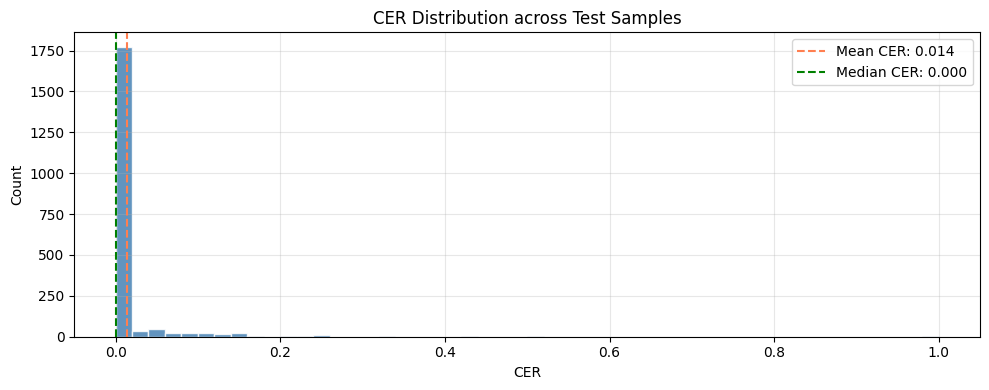

Mean CER   : 0.0142
Median CER : 0.0000
Std CER    : 0.0604
% perfect  : 88.6%
% CER < 0.1: 95.0%
% CER > 0.5: 0.2%


In [15]:
# Cell 9 — CER distribution across all samples (shows consistency)
import matplotlib.pyplot as plt
from jiwer import cer as cer_single
import numpy as np

sample_cers = []
for p, l in zip(all_preds, all_labels):
    if len(l) > 0:
        try:
            sample_cers.append(cer_single([l], [p]))
        except:
            pass

sample_cers = np.array(sample_cers)

plt.figure(figsize=(10, 4))
plt.hist(sample_cers, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(np.mean(sample_cers), color="coral",  linestyle="--", label=f"Mean CER: {np.mean(sample_cers):.3f}")
plt.axvline(np.median(sample_cers), color="green", linestyle="--", label=f"Median CER: {np.median(sample_cers):.3f}")
plt.title("CER Distribution across Test Samples")
plt.xlabel("CER"), plt.ylabel("Count")
plt.legend(), plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/cer_distribution.png", dpi=150)
plt.show()

print(f"Mean CER   : {np.mean(sample_cers):.4f}")
print(f"Median CER : {np.median(sample_cers):.4f}")
print(f"Std CER    : {np.std(sample_cers):.4f}")
print(f"% perfect  : {(sample_cers == 0).mean()*100:.1f}%")
print(f"% CER < 0.1: {(sample_cers < 0.1).mean()*100:.1f}%")
print(f"% CER > 0.5: {(sample_cers > 0.5).mean()*100:.1f}%")

In [16]:
# Cell 10 — error analysis by text length (short vs long lines)
short_preds  = [(p,l) for p,l in zip(all_preds, all_labels) if len(l) <= 10]
medium_preds = [(p,l) for p,l in zip(all_preds, all_labels) if 10 < len(l) <= 30]
long_preds   = [(p,l) for p,l in zip(all_preds, all_labels) if len(l) > 30]

def avg_cer(pairs):
    scores = []
    for p, l in pairs:
        if len(l) > 0:
            try: scores.append(cer_single([l], [p]))
            except: pass
    return np.mean(scores) if scores else 0

print(f"Short lines  (≤10 chars)  n={len(short_preds):>5}  CER: {avg_cer(short_preds):.4f}")
print(f"Medium lines (11-30 chars) n={len(medium_preds):>5}  CER: {avg_cer(medium_preds):.4f}")
print(f"Long lines   (>30 chars)  n={len(long_preds):>5}  CER: {avg_cer(long_preds):.4f}")

Short lines  (≤10 chars)  n= 1229  CER: 0.0096
Medium lines (11-30 chars) n=  659  CER: 0.0193
Long lines   (>30 chars)  n=  112  CER: 0.0348


In [17]:
# Cell 11 — worst predictions (failure case analysis for report)
errors = [(cer_single([l],[p]), l, p) 
          for p,l in zip(all_preds, all_labels) 
          if len(l) > 0]
errors.sort(reverse=True)

print("TOP 15 WORST PREDICTIONS")
print(f"{'CER':>6}  {'LABEL':<35} {'PREDICTION':<35}")
print("-" * 80)
for c, l, p in errors[:15]:
    print(f"{c:>6.3f}  {l[:35]:<35} {p[:35]:<35}")

TOP 15 WORST PREDICTIONS
   CER  LABEL                               PREDICTION                         
--------------------------------------------------------------------------------
 1.000  V                                   VI                                 
 1.000  A                                   ^                                  
 0.667  UJI                                 U01                                
 0.583  1 SMALL CONE                        1 SMALL COME AGAVE                 
 0.533  NET AMT @ GST6%                     WWX AMT 6%                         
 0.500  VE                                  VI                                 
 0.500  3383                                3843                               
 0.500  1.13                                11                                 
 0.438  T H A N K  Y O U                    THANK YOU                          
 0.438  CASHIER: THANDAR                    CASHIER: NICOLE                    
 0.429  67.67 

In [18]:
# Cell 12 — best predictions (show model strengths)
errors_best = sorted(errors)
print("TOP 15 BEST PREDICTIONS (CER = 0)")
print(f"{'CER':>6}  {'LABEL':<35} {'PREDICTION':<35}")
print("-" * 80)
for c, l, p in errors_best[:15]:
    if len(l) > 3:  # skip trivial single chars
        print(f"{c:>6.3f}  {l[:35]:<35} {p[:35]:<35}")

TOP 15 BEST PREDICTIONS (CER = 0)
   CER  LABEL                               PREDICTION                         
--------------------------------------------------------------------------------
 0.000  #01-01                              #01-01                             
 0.000  #1010802                            #1010802                           
 0.000  $1.60                               $1.60                              
 0.000  $6.60                               $6.60                              
 0.000  $7.10                               $7.10                              
 0.000  $7.10                               $7.10                              
 0.000  $7.10                               $7.10                              
 0.000  $7.60                               $7.60                              
 0.000  $8.20                               $8.20                              
 0.000  ( GST REG. NO. 000992739328 )       ( GST REG. NO. 000992739328 )      
 0.00

In [19]:
# Cell 13 — training curves (load from history saved during training)
import json

# load from the committed output of project-trocr
with open("/kaggle/input/project-trocr/training_history.json") as f:
    history = json.load(f)

epochs = range(1, len(history["train_losses"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_losses"], marker="o", color="steelblue", linewidth=2)
ax1.set_title("Training Loss per Epoch")
ax1.set_xlabel("Epoch"), ax1.set_ylabel("Loss")
ax1.grid(alpha=0.3)

ax2.plot(epochs, history["val_cers"], marker="o", color="coral", linewidth=2)
ax2.axhline(min(history["val_cers"]), linestyle="--", color="gray", alpha=0.5, label=f"Best: {min(history['val_cers']):.4f}")
ax2.set_title("Validation CER per Epoch")
ax2.set_xlabel("Epoch"), ax2.set_ylabel("CER")
ax2.legend(), ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/project-trocr/training_history.json'

In [20]:
# Cell 14 — summary table for report
print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Test CER            : {test_cer:.4f}  ({(1-test_cer)*100:.2f}% char accuracy)")
print(f"Test WER            : {test_wer:.4f}  ({(1-test_wer)*100:.2f}% word accuracy)")
print(f"Exact Match Rate    : {exact_rate*100:.2f}%")
print(f"Median Sample CER   : {np.median(sample_cers):.4f}")
print(f"% perfect lines     : {(sample_cers==0).mean()*100:.1f}%")
print(f"% lines CER < 0.1   : {(sample_cers<0.1).mean()*100:.1f}%")
print("-" * 50)
print(f"Best Val CER        : {min(history['val_cers']):.4f} (epoch {history['val_cers'].index(min(history['val_cers']))+1})")
print(f"Model               : microsoft/trocr-base-printed (fine-tuned)")
print(f"Training samples    : 10,000")
print(f"Test samples        : {len(all_labels)}")
print("=" * 50)

FINAL RESULTS SUMMARY
Test CER            : 0.0203  (97.97% char accuracy)
Test WER            : 0.0856  (91.44% word accuracy)
Exact Match Rate    : 88.65%
Median Sample CER   : 0.0000
% perfect lines     : 88.6%
% lines CER < 0.1   : 95.0%
--------------------------------------------------


NameError: name 'history' is not defined